# Conflicting constraints: robust vs ordinary expectation

Three continuous variables `A, B, C` on `[0, 100]`, discretised for a tensor-chain
Born machine. We ask each to be biased high,

    P(A>50) > 0.6,   P(B>50) > 0.6,   P(C>50) > 0.6,

and we impose **two conditional means on `B` that flatly contradict each other**:

    E[B | A>50] = 85          "when A is high, B is high"
    E[B | C>30] =  5          "when C exceeds 30, B is low"

Because both conditioning events are common (each variable spends most of its mass
above the threshold), the two demands overlap heavily and **cannot both be true**.

- With **ordinary** (hard squared-error) constraints the optimiser has no way out:
  it splits the difference and lands `E[B|A>50]` and `E[B|C>30]` at some
  intermediate compromise, satisfying *neither*.
- With **robust** constraints each target is modelled as an uncertain latent
  (`spike-and-slab`): the model may keep one belief on its spike and *explain the
  other away into its slab*. The learned spike mass is a readable **credence** in
  each constraint.

In [ ]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import numpy as np, jax.numpy as jnp
import matplotlib.pyplot as plt

from calibrated_response.tn import TensorChain, ContinuousVar, latent_var, plot_pairwise, losses as L

# one-sided "P(X_site > thr) >= floor" penalty (hinge; only bites when violated)
def hinge(site, thr=50.0, floor=0.62, w=25.0):
    def reg(m, p):
        return w * jnp.clip(floor - m.event_prob(p, {site: m.threshold_mask(site, thr)}), 0.0, None) ** 2
    return reg

def show_marginals(m, p, sites, labels):
    parts = [f"P({lab}>50)={float(m.event_prob(p, {s: m.threshold_mask(s, 50.)})):.2f}"
             for s, lab in zip(sites, labels)]
    print("   marginals:  " + "   ".join(parts))

## 1. Ordinary (hard) constraints

Sites `A=0, B=1, C=2`. The two conditional means enter as `("cond_expect", B, given, target)`
constraints; the three `P(X>50)` floors as hinge regularizers; a mild `curvature`
term keeps the free part of each marginal smooth.

ORDINARY  --  final loss 4.078e-01
   marginals:  P(A>50)=0.60   P(B>50)=0.56   P(C>50)=0.55
   E[B | A>50] =  83.0   (target 85)
   E[B | C>30] =  14.0   (target  5)
   -> neither target is met: the hard constraints average out to a compromise.


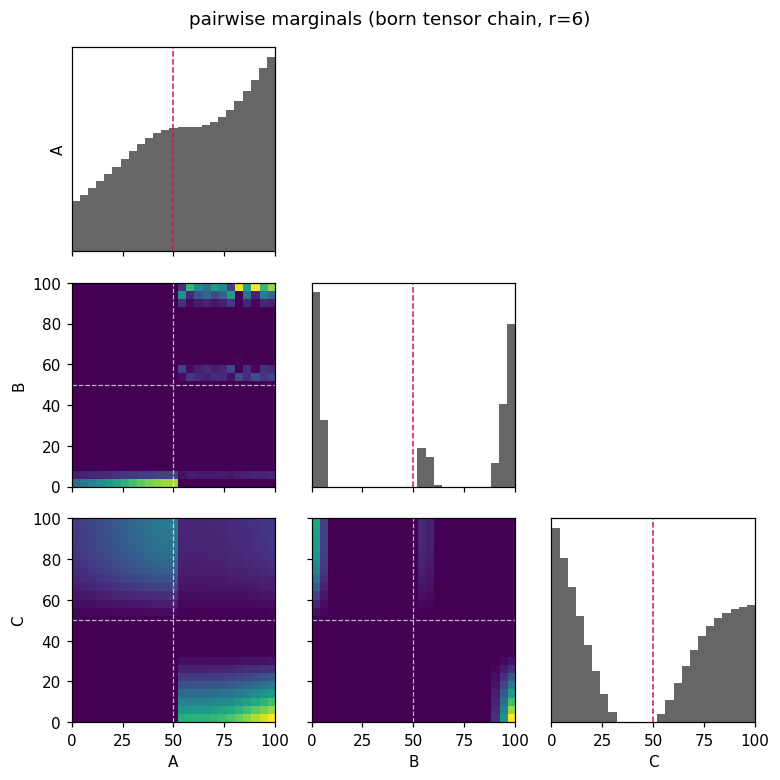

In [ ]:
varsN = [ContinuousVar("A", 0, 100, 25), ContinuousVar("B", 0, 100, 25), ContinuousVar("C", 0, 100, 25)]
mN = TensorChain(varsN, bond_dim=6, kind="born")
maskA = mN.threshold_mask(0, 50.0)     # event A>50
maskC = mN.threshold_mask(2, 30.0)     # event C>30

consN = [("cond_expect", 1, {0: maskA}, 85.0, 2e-3),
         ("cond_expect", 1, {2: maskC},  5.0, 2e-3)]
regsN = [(hinge(0), 1.0), (hinge(1), 1.0), (hinge(2), 1.0), ("curvature", 2.0)]

pN, hN = mN.optimize(L.combined_loss(mN, consN, regsN), backend="adam", steps=2500, lr=3e-2, seed=0)
print(f"ORDINARY  --  final loss {hN[-1]:.3e}")
show_marginals(mN, pN, (0, 1, 2), ("A", "B", "C"))
print(f"   E[B | A>50] = {float(mN.cond_expectation(pN, 1, {0: maskA})):5.1f}   (target 85)")
print(f"   E[B | C>30] = {float(mN.cond_expectation(pN, 1, {2: maskC})):5.1f}   (target  5)")
print("   -> neither target is met: the hard constraints average out to a compromise.")
_FIG = plot_pairwise(mN, pN, threshold=50)[0]

## 2. Robust (spike-and-slab) constraints

Each target becomes an uncertain **latent site**. We place the chain as
`A, cA, B, cC, C` so that `B` (site 2) is adjacent to *both* latents `cA` (site 1,
the uncertain value of `E[B|A>50]`) and `cC` (site 3, that of `E[B|C>30]`); a
higher `bond_dim` gives the `B`--latent bonds room to carry the coupling.

`robust_expectation(x=B, c=cA, target=85, given={A: A>50})` reads the masked joint
`p(B, cA | A>50)`, pulls `E[B|cA, A>50]` toward `cA` (mass-weighted, division-free),
and pins `p(cA)` toward a spike-and-slab centred at 85. Same for `cC` at 5.

ROBUST  --  final loss 1.029e-02
   marginals:  P(A>50)=0.73   P(B>50)=0.64   P(C>50)=0.85
   E[B | A>50] =  59.9   (belief 85)   credence p(cA~85) = 0.64
   E[B | C>30] =  59.6   (belief  5)   credence p(cC~ 5) = 0.60


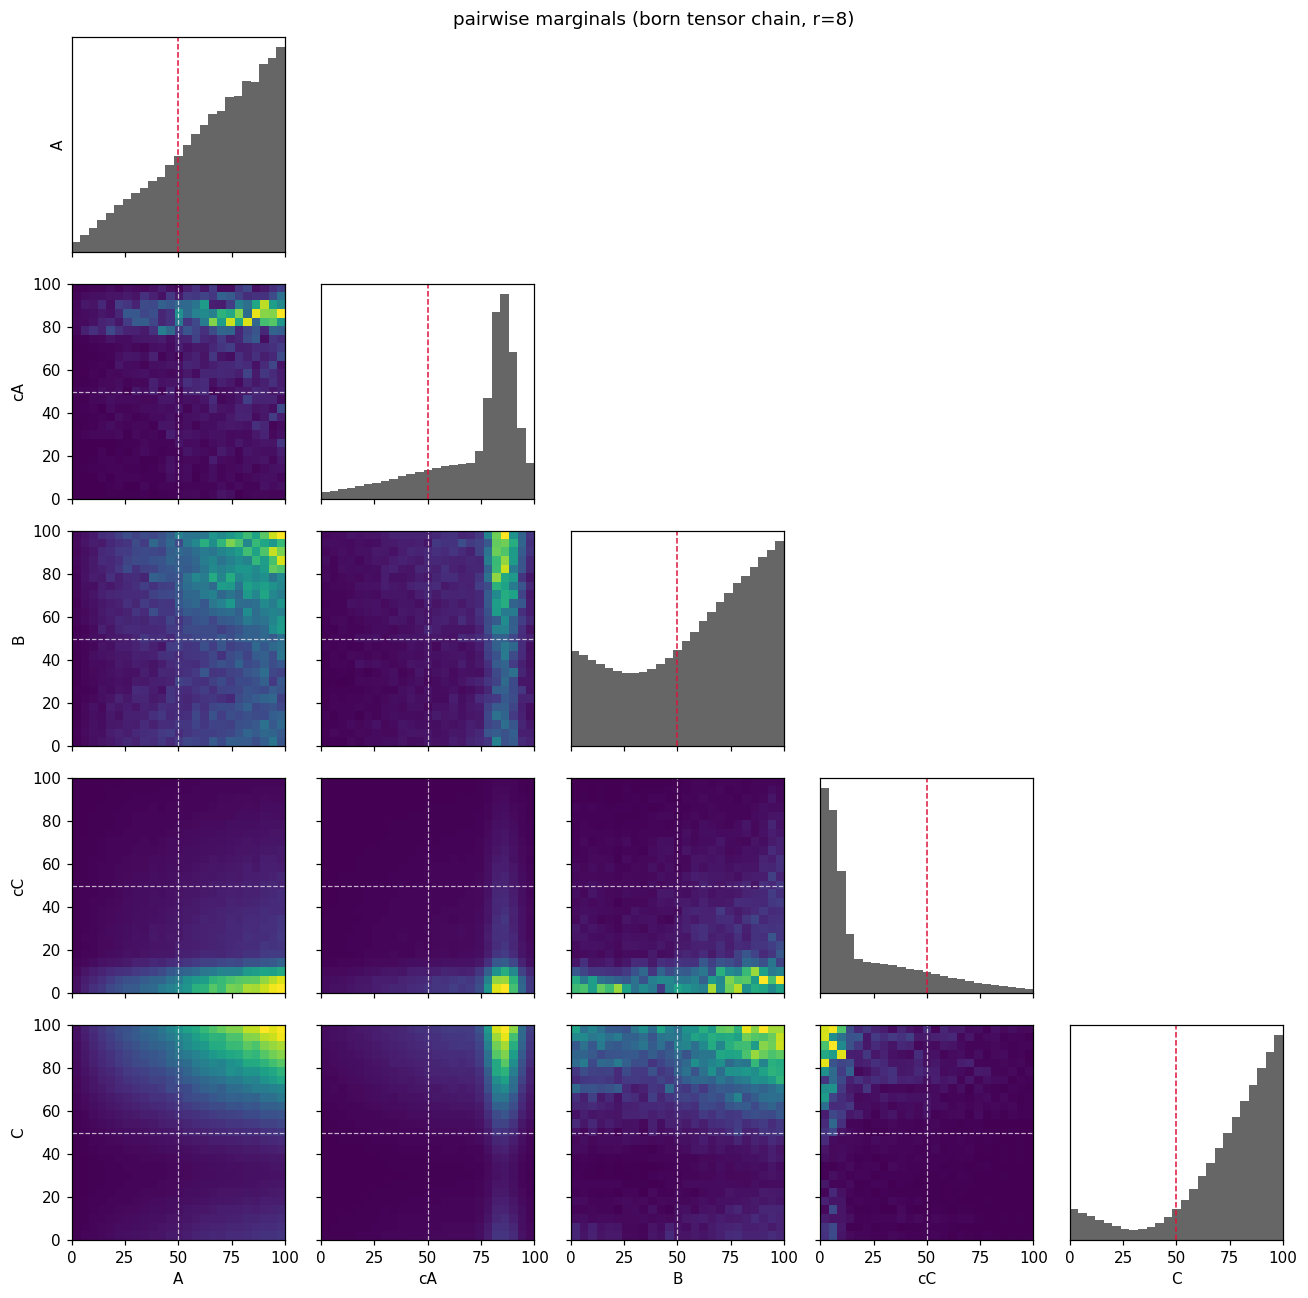

In [ ]:
varsR = [ContinuousVar("A", 0, 100, 25), latent_var("cA", 0, 100, 25),
         ContinuousVar("B", 0, 100, 25), latent_var("cC", 0, 100, 25),
         ContinuousVar("C", 0, 100, 25)]
mR = TensorChain(varsR, bond_dim=8, kind="born")
mA = mR.threshold_mask(0, 50.0)        # A>50  (site 0)
mC = mR.threshold_mask(4, 30.0)        # C>30  (site 4)

rob = [(L.robust_expectation(2, 1, 85.0, given={0: mA}, spike_sd=4., slab_sd=45.,
                             w_prior=0.3, w_couple=0.15), 1.0),
       (L.robust_expectation(2, 3,  5.0, given={4: mC}, spike_sd=4., slab_sd=45.,
                             w_prior=0.3, w_couple=0.15), 1.0)]
regsR = [(hinge(0), 1.0), (hinge(2), 1.0), (hinge(4), 1.0), ("curvature", 2.0)]

pR, hR = mR.optimize(L.combined_loss(mR, [], rob + regsR), backend="adam", steps=2500, lr=3e-2, seed=0)

def spike_mass(m, p, c_site, tgt, tol=12.0):
    pc = np.asarray(m.joint_marginal(p, c_site)); cc = m.disc.bin_centers(c_site)
    return float(pc[np.abs(cc - tgt) < tol].sum())

print(f"ROBUST  --  final loss {hR[-1]:.3e}")
show_marginals(mR, pR, (0, 2, 4), ("A", "B", "C"))
print(f"   E[B | A>50] = {float(mR.cond_expectation(pR, 2, {0: mA})):5.1f}   "
      f"(belief 85)   credence p(cA~85) = {spike_mass(mR, pR, 1, 85.):.2f}")
print(f"   E[B | C>30] = {float(mR.cond_expectation(pR, 2, {4: mC})):5.1f}   "
      f"(belief  5)   credence p(cC~ 5) = {spike_mass(mR, pR, 3, 5.):.2f}")
_FIG = plot_pairwise(mR, pR, threshold=50)[0]

### The latent target posteriors

The whole point is visible in `p(cA)` and `p(cC)`: a constraint the model keeps
sits as a sharp **spike** at its target; one it gives up on collapses into the
broad **slab**. The spike mass is the model's learned credence in that constraint.

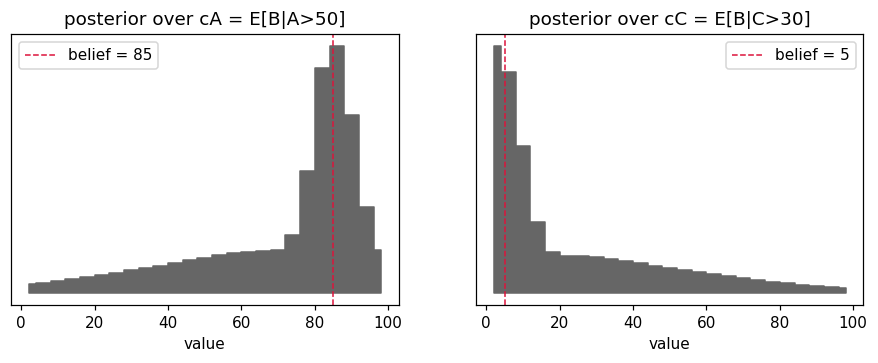

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, (c_site, tgt, lab) in zip(axes, [(1, 85., "cA = E[B|A>50]"), (3, 5., "cC = E[B|C>30]")]):
    pc = np.asarray(mR.joint_marginal(pR, c_site)); cc = mR.disc.bin_centers(c_site)
    ax.fill_between(cc, pc, step="mid", color="0.4")
    ax.axvline(tgt, color="crimson", ls="--", lw=1, label=f"belief = {tgt:.0f}")
    ax.set_title(f"posterior over {lab}"); ax.set_xlabel("value"); ax.set_yticks([]); ax.legend()
_FIG = fig

## What to take away

This conflict is *symmetric* -- the two beliefs are equally strong and equally
contradicted -- so watch **what each approach chooses to sacrifice**:

- **Ordinary constraints** chase both conditional means hard, and the only way to
  get `E[B|A>50]` near 85 while `E[B|C>30]` heads toward 5 is to **quietly break
  the `P(X>50)` floors** (they slip below 0.6): the optimiser distorts the very
  marginals you asked for in order to appear to satisfy contradictory demands, and
  nothing in the output flags the conflict.
- **Robust constraints** keep the `P(X>50)` floors intact and instead **hedge**:
  both conditional means settle in the middle (~60) and *both* credences
  `p(cA~85)`, `p(cC~5)` drop below 1 (~0.6) -- the model reports reduced trust in
  each contradicted belief rather than silently mangling the marginals. On a
  symmetric conflict it splits credence evenly; break the symmetry (raise one
  `spike_w`, or make one event rarer) and it tips toward the belief it can afford.
- The knob is `w_prior`: large pins the credence to your prior (fixed robustness);
  small lets the data (here, the mutual contradiction) *reshape* the credence.

For a case where robust cleanly **discards** a single bad constraint rather than
hedging a symmetric pair, see the single-variable false-constraint notebook.

Everything is read off exact contractions -- `cond_expectation` and the masked
`joint_marginal` -- so both the fit and the diagnostics are defined directly on the
model's marginals, no sampling.